In [25]:
import libcontext
from src.adagram_optimizers.utils.Dataset import Dataset
import numpy as np 
import torch
from scipy.linalg import toeplitz

class CorrelatedAnisotropicDataset(Dataset):
    def __init__(self, n_samples=1000, in_dim=20, out_dim=2, rho=0.8, seed=42):
        self.n_samples = n_samples
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.rho = rho
        # Use a consistent seed for reproducibility
        self.rng = np.random.default_rng(seed)

    def create_data(self):
        # 1) Generate base i.i.d. standard normal data
        Z = self.rng.normal(loc=0.0, scale=1.0, size=(self.n_samples, self.in_dim))

        # 2) Define a *valid* target correlation matrix
        # C_ij = rho^|i-j|. This creates a valid positive-definite matrix.
        c = self.rho**np.arange(self.in_dim)
        target_corr_matrix = toeplitz(c)

        # 3) Compute the Cholesky decomposition
        # L @ L.T = target_corr_matrix
        try:
            L = np.linalg.cholesky(target_corr_matrix)
        except np.linalg.LinAlgError:
            # This should not happen with the toeplitz matrix,
            # but it's good practice for other custom matrices.
            print("Error: The target correlation matrix is not positive definite.")
            return None, None
            
        # 4) Create the correlated data by transforming Z with L
        # The covariance of X will now be L @ L.T = target_corr_matrix
        X = Z @ L.T
        
        # 5) Generate labels from the correlated features
        # (Assuming you have this method defined elsewhere)
        # y = self._generate_labels(X)
        # For demonstration, let's create dummy labels
        y = self.rng.integers(0, 2, size=(self.n_samples, self.out_dim))

        # 6) Convert final numpy arrays to torch tensors
        return torch.from_numpy(X).float(), torch.from_numpy(y).long().flatten()

In [21]:
import libcontext
from src.adagram_optimizers.utils.Dataset import Dataset
import numpy as np 
import torch

class CorrelatedAnisotropicDataset(Dataset):
    """
    A concrete implementation that generates a dataset with correlated features,
    which is the key to creating an anisotropic loss landscape for logistic regression.
    """
    def create_data(self, anisotropy_ratio=1e3):
        # 1. Start with uncorrelated data
        Z = self.rng.standard_normal(size=(self.n_samples, self.in_dim))

        # 2. Create a tridiagonal matrix T
        #    - Main diagonal of 1s
        #    - Off-diagonals of 0.5 to create local correlation
        T = np.zeros((self.in_dim, self.in_dim))
        
        # Set the main diagonal
        rng = np.random.default_rng(42)
        diag_values = list(1 + rng.normal(0, 0.05, size=self.in_dim))
        np.fill_diagonal(T, diag_values)

        # 3. Apply the rotation to create the final correlated weight vector
        upper_diag = T.diagonal(offset=1)
        upper_diag.setflags(write=True)
        upper_vals = list(1 + rng.uniform(0.5, 0.55, size=self.in_dim - 1))
        upper_diag[:] = upper_vals
        # upper_diag.fill(0.7)

        lower_diag = T.diagonal(offset=-1)
        lower_diag.setflags(write=True)
        lower_vals = list(1 + rng.uniform(0.5, 0.55, size=self.in_dim - 1))
        lower_diag[:] = lower_vals

        X = Z @ T 

        # 4. Generate the probabilistic logistic regression labels
        y = self._generate_labels(X)

        return X, torch.tensor(y.reshape(-1), dtype=torch.long)

Running for CorrelatedAnisotropic
Starting Full Dataset Geometric Analysis
--- Scaling features to remove scale-based anisotropy ---
Scaling complete.

--- Analyzing feature correlation ---


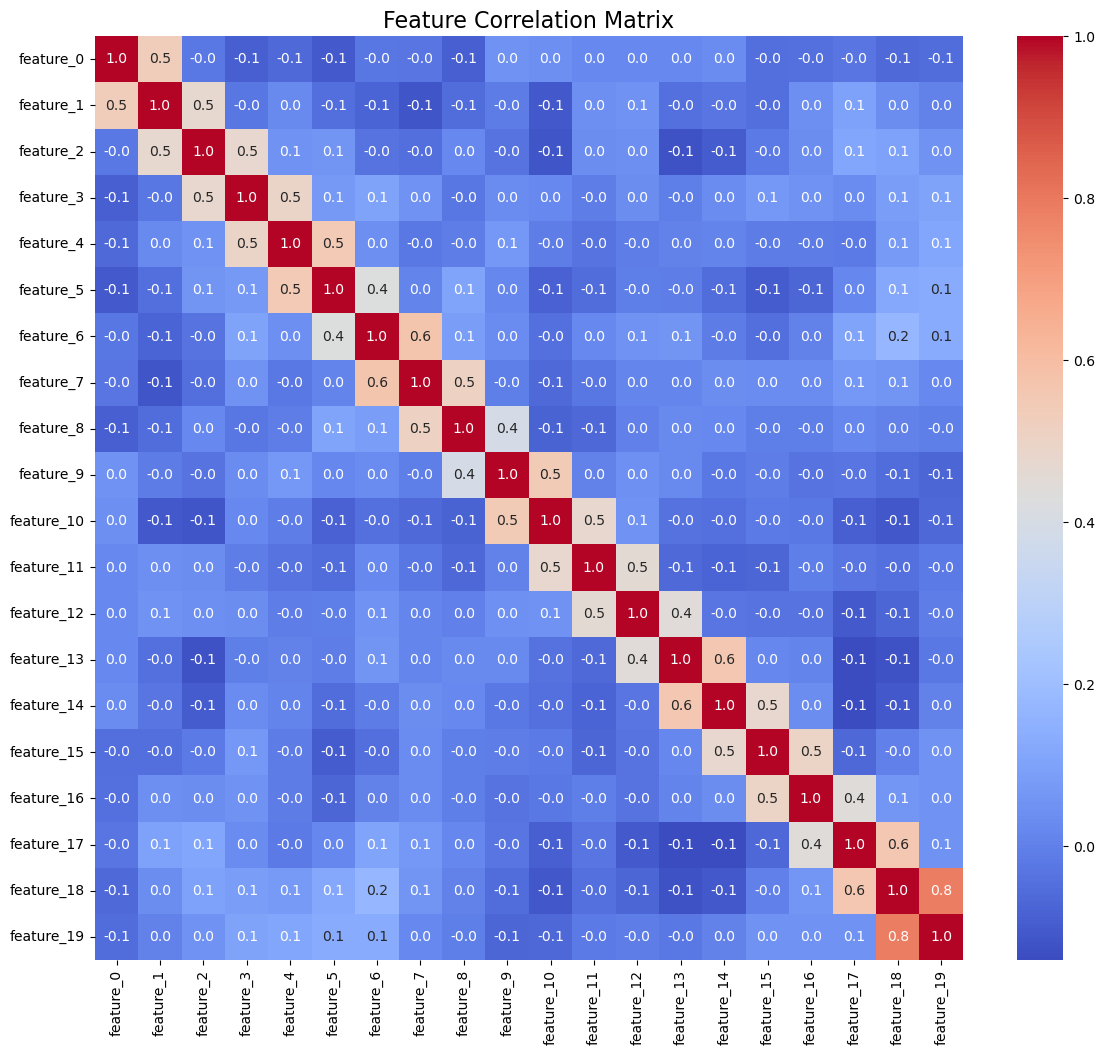


--- Analyzing structural anisotropy with PCA ---


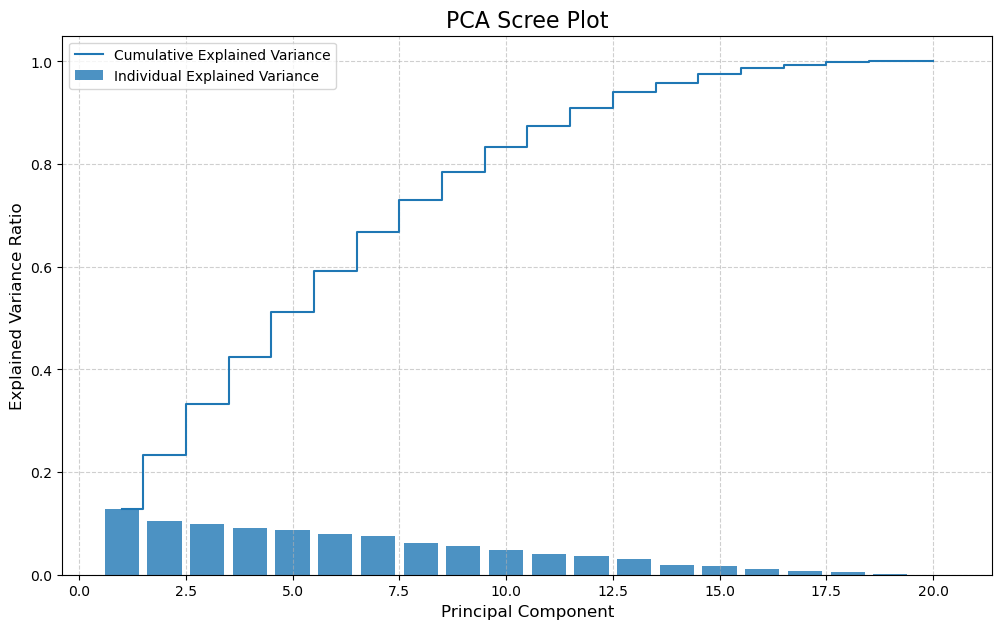


Analysis complete. See plots for visualization.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
import libcontext


from src.adagram_optimizers.utils.Dataset import AustralianCreditDataset, HeartDataset, MNISTDataWrapper, SpliceDataset, IsotropicDataset, AnisotropicDataset, SparseDataset, CorrelatedAnisotropicDataset



class DatasetAnalyzer:
    def __init__(self, dataset_loader):
        """
        Initializes the analyzer with a data loading object.
        
        Args:
            dataset_loader: An object with a 'get_data_for_analysis' method
                            that returns X (pd.DataFrame) and y (np.array).
        """
        self.loader = dataset_loader
        self.X_raw, self.y_raw = self.loader.get_data_for_analysis()
        self.X_scaled_df = None
        

    def _scale_features(self):
        """Scales the features using StandardScaler."""
        print("--- Scaling features to remove scale-based anisotropy ---")
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(self.X_raw)
        self.X_scaled_df = pd.DataFrame(X_scaled, columns=self.X_raw.columns)
        print("Scaling complete.")

    def analyze_correlation(self):
        """Calculates and visualizes the feature correlation matrix."""
        if self.X_scaled_df is None:
            self._scale_features()
            
        print("\n--- Analyzing feature correlation ---")
        correlation_matrix = self.X_raw.corr()
        
        plt.figure(figsize=(14, 12))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".1f")
        plt.title('Feature Correlation Matrix', fontsize=16)
        plt.show()

    def analyze_isotropy_with_pca(self):
        """Performs PCA to analyze structural anisotropy."""
        # if self.X_scaled_df is None:
        #     self._scale_features()

        print("\n--- Analyzing structural anisotropy with PCA ---")
        pca = PCA()
        pca.fit(self.X_raw)
        
        explained_variance_ratio = pca.explained_variance_ratio_

        plt.figure(figsize=(12, 7))
        plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.8, align='center', label='Individual Explained Variance')
        plt.step(range(1, len(explained_variance_ratio) + 1), np.cumsum(explained_variance_ratio), where='mid', label='Cumulative Explained Variance')
        plt.ylabel('Explained Variance Ratio', fontsize=12)
        plt.xlabel('Principal Component', fontsize=12)
        plt.title('PCA Scree Plot', fontsize=16)
        plt.legend(loc='best')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

    def run_full_analysis(self):
        """Runs all analysis steps in sequence."""
        print("="*50)
        print("Starting Full Dataset Geometric Analysis")
        print("="*50)
        self.analyze_correlation()
        self.analyze_isotropy_with_pca()
        print("\nAnalysis complete. See plots for visualization.")
        print("="*50)


# --- Main Execution ---
if __name__ == "__main__":
    # 1. Create an instance of your data loade
    # loaders = {
    # "AU": AustralianCreditDataset(), 
    # "Heart": HeartDataset(), 
    # "Splice": SpliceDataset(),
    # "MNIST": MNISTDataWrapper()
    # }
    n_samples = 300
    in_dim = 20
    out_dim = 2
    test_size = 0.2
    seed = 10

    loaders = {
    #     # "LogisticAnisotropicDataset": LogisticAnisotropicDataset(n_samples=n_samples, in_dim=in_dim, out_dim=out_dim, seed=seed,),
    #     # "Anisotropic": AnisotropicDataset(n_samples=n_samples, in_dim=in_dim, out_dim=out_dim, seed=seed,), 
        "CorrelatedAnisotropic": CorrelatedAnisotropicDataset(n_samples=n_samples,in_dim=in_dim,out_dim=out_dim,seed=seed,),
    #     # "SparseDataset": SparseDataset(
    #         #     sparsity_rate_1=0.1,
    #         #     sparsity_rate_2=0.5,
    #         #     n_samples=n_samples,
    #         #     in_dim=in_dim,
    #         #     out_dim=out_dim,
    #         #     seed=seed,
    #         #     if_class=True,
    #         # )
        }
    
    for loader_name in loaders.keys():
        # 2. Pass it to the analyzer
        analyzer = DatasetAnalyzer(loaders[loader_name])

        print(f"Running for {loader_name}") 
        # 3. Run the full analysis
        analyzer.run_full_analysis()